# preprocess/ demo

Raw GE ScanArchives for one sequence → one file, `<outdir>/<seq>_preprocessed.h5`,
holding everything `recon/` needs: zero-filled k-space, sensitivity maps, B0 and
R2* maps. This notebook walks through each step on `20260915ball/2_6x_2.4mm`
(ball phantom, 2.4 mm, R = 6, 60 frames) and is also the place to set the
options: edit **Settings** and run it, or use the same `PreprocessConfig` from
the command line (`python -m preprocess.batch_preprocess`).

The pipeline, `preprocess(cfg, seq)`:

1. **Stage A** (always, cached in `<seq>_gridded.h5`): noise whitening, the readout
   delay and the odd/even (Nyquist ghost) phase, both calibrated on the calibration
   scan, then for every EPI
   frame ramp-sample gridding, odd/even correction and scatter into the zero-filled
   (kx, ky, kz) grid — on all physical coils.
2. **Coil compression** (optional): GCC, one matrix per readout position x.
3. **Maps** from the dual-echo deGRE: ESPIRiT sensitivities, B0 (MRIFieldmaps.jl), R2*.
4. **Stage B**: apply the compression to the cached k-space, cut out the fully
   sampled calibration region, and write everything to one file.

Runs in `.venv-preprocessing` (GERecon for the raw archives, and `julia` on PATH for B0).

In [1]:
import os
import sys
import time
import warnings
from dataclasses import replace
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

warnings.filterwarnings("ignore", message="IProgress not found")  # tqdm, via sigpy
REPO = Path.cwd().parent if Path.cwd().name == "preprocess" else Path.cwd()
sys.path.insert(0, str(REPO))

from preprocess import utils  # noqa: E402
from preprocess.coils import compute_whitening_matrix  # noqa: E402
from preprocess.preprocess import (  # noqa: E402
    PreprocessConfig,
    calibrate_odd_even,
    compute_oephase,
    prepare_cal_data,
    preprocess,
    set_seq_paths,
)

## Settings

Every option of `PreprocessConfig` (`preprocess/preprocess.py`), with its default:

| Option | Default | What it does |
|---|---|---|
| `outdir` | `<datdir>/recon` | where the output (and the cache) go; `recon/` looks in `<datdir>/recon` |
| `compress` | `True` | coil-compress the output; `False` keeps all physical coils |
| `cc_energy_thresh` | `0.999` | keep the fewest virtual coils holding this fraction of the eigenvalue energy |
| `Nvcoils` | `None` | exact number of virtual coils; overrides `cc_energy_thresh` |
| `estimate_smaps` / `estimate_b0` / `estimate_r2star` | `True` | which maps to make (B0 needs `julia`) |
| `crop` | `0.95` | ESPIRiT eigenvalue threshold (also the map support) |
| `smaps_smooth_sigma_mm` | `6.0` | smoothing of the maps on the EPI grid |
| `b0map_mask_thresh` | `0.1` | fraction of peak echo-1 magnitude the B0 fit covers |
| `zero_pad_z` | `False` | zero-fill EPI slices outside the deGRE slab instead of failing |
| `extract_calib` | `True` | write the fully sampled calibration region `ksp_calib` |
| `keep_cache` | `False` | keep `<seq>_gridded.h5`, so a rerun with other compression settings skips Stage A |

The readout delay is not an option either: it is calibrated for every sequence (section 2).
Whitening is not an option: it is applied whenever the sequence has a noise scan
(it is lossless, and everything downstream assumes white, unit-variance noise).

In [2]:
DATDIR = "/StorageRAID/rexfung/20260915ball"
SEQ = "2_6x_2.4mm"
OUTDIR = os.environ.get("PREPROCESS_DEMO_OUTDIR")  # None -> <DATDIR>/recon

cfg = PreprocessConfig(datdir=DATDIR, seqnames=[SEQ], outdir=OUTDIR, keep_cache=True)
paths = set_seq_paths(cfg, SEQ)
sp = utils.load_seq_params(paths.scan_info)
print(sp)

SeqParams(Nx=90, Ny=90, Nz=60, ETL=60, R=6, fov=(0.21599999999999997, 0.21599999999999997, 0.144), volume_tr=1.0, discard_duration=0, Nx_degre=108, Ny_degre=108, Nz_degre=72, fov_degre=(0.216, 0.216, 0.14400000000000002), n_echoes_degre=2, TE_degre=(0.0030368962616989675, 0.0052737925233979355))


## 1. Raw data

Each sequence has a noise scan (receiver on, no RF), a calibration scan (EPI echo
trains with the phase-encoding blips off) and the EPI time series; the deGRE is a
separate, fully sampled dual-echo GRE shared by all sequences. Readouts are
ramp-sampled: `Nfid` samples on a trapezoidal gradient, not `Nx` evenly spaced ones.
The whitening matrix `W` makes the 32 channels' noise uncorrelated with unit variance.

noise (104, 32, 197), calibration (104, 32, 900), Nx = 90, ETL = 60


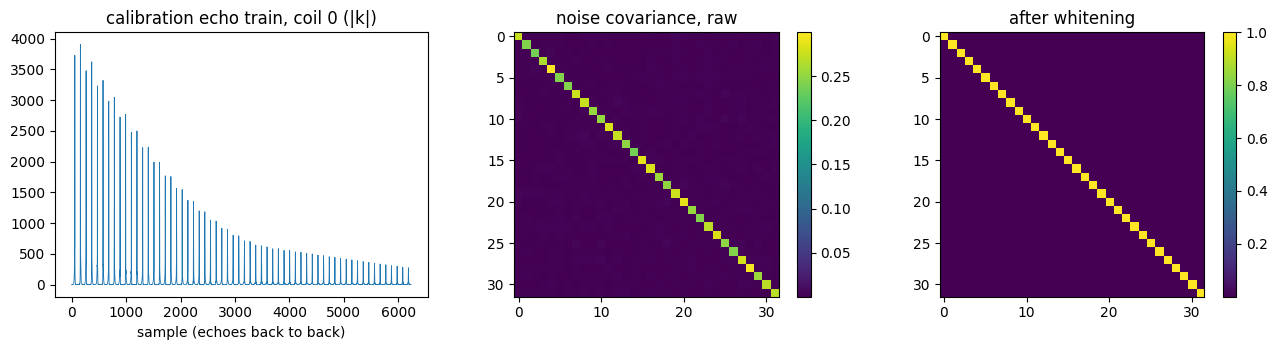

In [3]:
noise = utils.read_archive(paths.noise)  # [Nfid, Ncoils, Nacq]
cal_raw = utils.read_archive(paths.cal)
print(f"noise {noise.shape}, calibration {cal_raw.shape}, Nx = {sp.Nx}, ETL = {sp.ETL}")

W = compute_whitening_matrix(noise.transpose(0, 2, 1))
x = noise.transpose(0, 2, 1).reshape(-1, noise.shape[1])
cov_raw = x.T @ x.conj() / len(x)
xw = x @ W.conj().T
cov_white = xw.T @ xw.conj() / len(xw)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].plot(np.abs(cal_raw[:, 0, : sp.ETL]).T.ravel(), lw=0.6)
ax[0].set_title("calibration echo train, coil 0 (|k|)")
ax[0].set_xlabel("sample (echoes back to back)")
for a, c, t in [(ax[1], cov_raw, "noise covariance, raw"), (ax[2], cov_white, "after whitening")]:
    im = a.imshow(np.abs(c), cmap="viridis")
    a.set_title(t)
    plt.colorbar(im, ax=a)
plt.tight_layout()
plt.show()

## 2. Readout delay and odd/even correction

EPI reads odd and even echoes in opposite directions, and any timing or eddy-current
mismatch between them leaves a phase difference that ghosts the image by FOV/2. The
calibration scan has no phase encoding, so after regridding each echo is the same 1D
profile; the phase between neighboring odd/even echoes, `th(x)`, is fit with a
constant + linear model `a` and removed from every even echo of every frame.

The regridding needs the readout's k-space center offset (the delay, in samples),
which depends on the scanner and readout. A wrong delay shifts odd and even echoes
in opposite directions in kx, i.e. adds a linear term to `th(x)`, and once that passes
±π inside the object the fit breaks. So the delay is swept (−6 to +6 samples) on the
same calibration data, and the one with no phase wraps and the smallest linear term is
kept (left). Everything here uses whitened, uncompressed data; the grey band is where
wraps are counted and the fit is done.

  readout delay (k-space center offset): -0.35 samples, calibrated


  odd/even phase: constant -0.3084 rad, linear -0.2197 rad/FOV


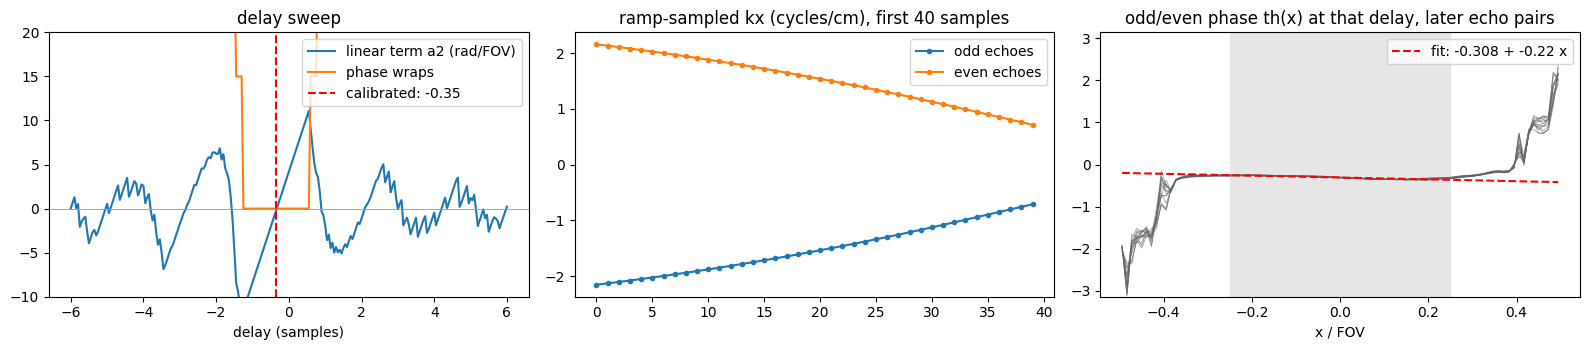

In [4]:
fov_x_cm = sp.fov[0] * 100
kxo, kxe, a, sweep = calibrate_odd_even(cal_raw, W, None, paths.scan_info, sp.Nx, sp.ETL, fov_x_cm)
_, th = compute_oephase(prepare_cal_data(cal_raw, W, None, sp.ETL), kxo, kxe, sp.Nx, fov_x_cm)
xc = (np.arange(sp.Nx) - sp.Nx / 2 + 0.5) / sp.Nx

fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
ax[0].plot(sweep["delay"], sweep["a2"], label="linear term a2 (rad/FOV)")
ax[0].plot(sweep["delay"], sweep["wrap_count"], label="phase wraps")
ax[0].axvline(sweep["best"], color="r", ls="--", label=f"calibrated: {sweep['best']:+.2f}")
ax[0].axhline(0, color="0.6", lw=0.6)
ax[0].set_ylim(-10, 20)
ax[0].set_title("delay sweep")
ax[0].set_xlabel("delay (samples)")
ax[0].legend()
ax[1].plot(kxo[:40], "o-", ms=3, label="odd echoes")
ax[1].plot(kxe[:40], "o-", ms=3, label="even echoes")
ax[1].set_title("ramp-sampled kx (cycles/cm), first 40 samples")
ax[1].legend()
ax[2].plot(xc, th[:, th.shape[1] // 2:], color="0.4", lw=0.6, alpha=0.6)
ax[2].plot(xc, a[0] + a[1] * xc, "r--", lw=1.5, label=f"fit: {a[0]:.3f} + {a[1]:.2f} x")
ax[2].axvspan(xc[sp.Nx // 4], xc[3 * sp.Nx // 4], color="0.9", zorder=-1)
ax[2].set_title("odd/even phase th(x) at that delay, later echo pairs")
ax[2].set_xlabel("x / FOV")
ax[2].set_ylim(-np.pi, np.pi)
ax[2].legend()
plt.tight_layout()
plt.show()

## 3. Run the pipeline

About 7 minutes for this dataset: Stage A (the delay sweep, then gridding 60 frames ×
900 readouts on 32 coils) is roughly a third, the rest is ESPIRiT, the B0 fit in Julia and writing.
Output is printed as it goes.

In [5]:
t0 = time.time()
out = preprocess(cfg, SEQ)
print(f"{time.time() - t0:.0f} s")

=== 2_6x_2.4mm ===
Stage A: calibration


  readout delay (k-space center offset): -0.35 samples, calibrated


  odd/even phase: constant -0.3084 rad, linear -0.2197 rad/FOV


Stage A: gridding frames 1-60 (900 shots each)


  frame 1/60


...

[ Info: 21 of 30


Wrote '/tmp/user/1015/tmpmdr89z9p/b0map.h5'.


Calibration region: ky 37:54, kz 25:36
Stage B: writing /home/rexfung/.claude/jobs/8dfd3ab3/tmp/val_demo2/2_6x_2.4mm_preprocessed.h5


  thermal-noise variance of the output k-space: 0.9345


Done: /home/rexfung/.claude/jobs/8dfd3ab3/tmp/val_demo2/2_6x_2.4mm_preprocessed.h5
628 s


## 4. Zero-filled k-space and the calibration region

`omegas` is the (ky, kz) sampling mask of each frame (the same for every kx). The
fully sampled calibration region is the rectangle of (ky, kz) locations sampled in
**every** frame, grown outward from the k-space center; it is stored as `ksp_calib`
with the full kx extent, and its bounds as attributes.

ksp_epi_zf (90, 90, 60, 15, 60)  ksp_calib (90, 17, 11, 15, 60)


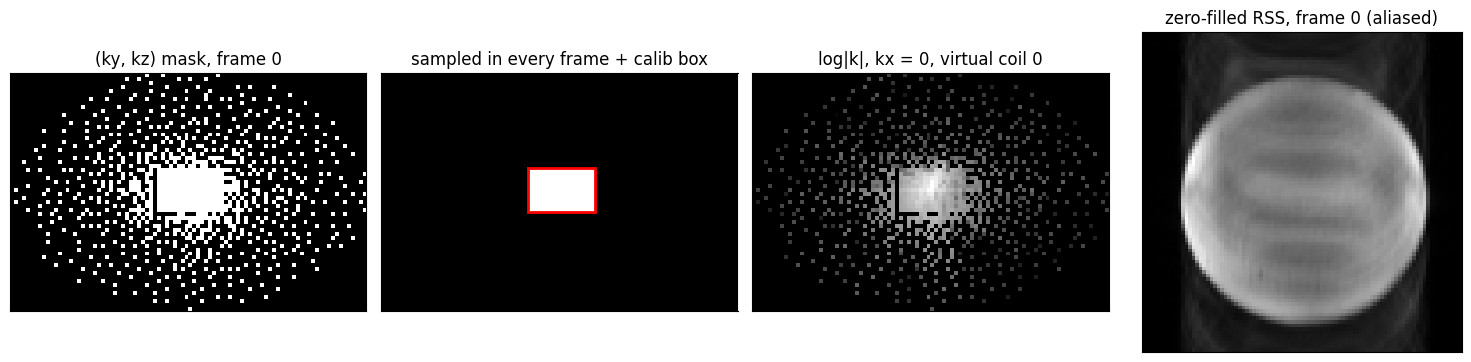

In [6]:
with h5py.File(out) as f:
    omegas = f["omegas"][()]
    y0, y1 = f["ksp_calib"].attrs["calib_y_range"]
    z0, z1 = f["ksp_calib"].attrs["calib_z_range"]
    k0 = f["ksp_epi_zf"][..., 0]  # frame 0, [Nx, Ny, Nz, Nv]
    print("ksp_epi_zf", f["ksp_epi_zf"].shape, " ksp_calib", f["ksp_calib"].shape)

common = omegas.all(axis=-1)
img0 = np.sqrt(np.sum(np.abs(utils.ift3c(k0)) ** 2, axis=-1))
fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
ax[0].imshow(omegas[..., 0].T, origin="lower", cmap="gray")
ax[0].set_title("(ky, kz) mask, frame 0")
ax[1].imshow(common.T, origin="lower", cmap="gray")
ax[1].add_patch(plt.Rectangle((y0 - 0.5, z0 - 0.5), y1 - y0, z1 - z0, fill=False, ec="r", lw=2))
ax[1].set_title("sampled in every frame + calib box")
ax[2].imshow(np.log1p(np.abs(k0[sp.Nx // 2, :, :, 0])).T, origin="lower", cmap="gray")
ax[2].set_title("log|k|, kx = 0, virtual coil 0")
ax[3].imshow(img0[:, :, sp.Nz // 2].T, origin="lower", cmap="gray")
ax[3].set_title("zero-filled RSS, frame 0 (aliased)")
for a_ in ax:
    a_.set_xticks([])
    a_.set_yticks([])
plt.tight_layout()
plt.show()

## 5. Coil compression (GCC)

The readout is fully sampled, so the k-space can be inverse-Fourier-transformed along
kx and compressed with a different matrix at each x position (Zhang et al., MRM 2013).
Only a few of the 32 coils see any one x, so each position's coil covariance has a
steep eigenvalue spectrum even though the whole volume's is flat. The number of virtual
coils is the smallest that keeps `cc_energy_thresh` of the eigenvalue energy summed over
all x (low-signal positions barely count). The same matrices are applied to the maps, so
data and maps stay consistent, and whitened noise stays white: `noise_var` ≈ 1.

32 -> 15 virtual coils (energy), 99.92% of energy kept; noise_var = 0.9345


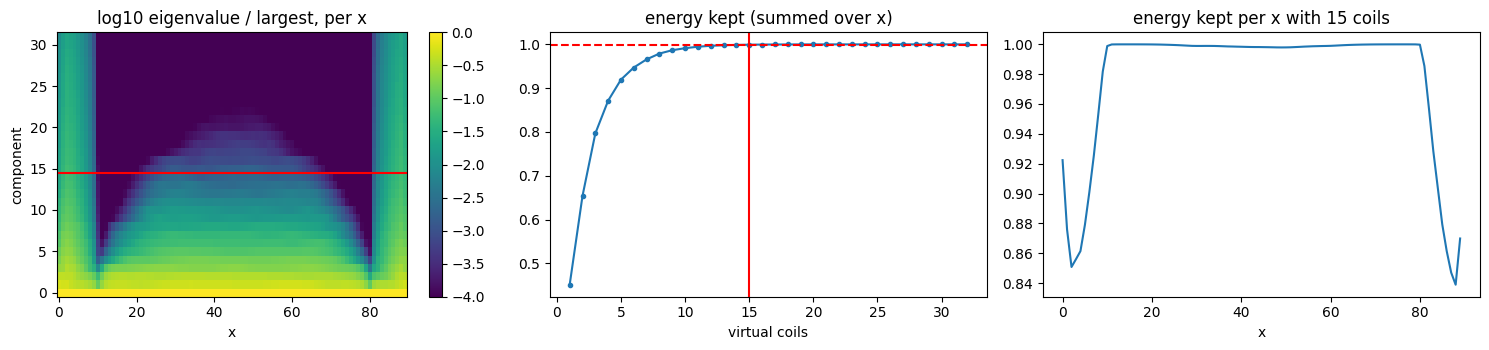

In [7]:
with h5py.File(out) as f:
    ev = f["cc_evals"][()]  # [Nx, Ncoils], per-x eigenvalues, descending
    nv, kept = f.attrs["Nvcoils"], f.attrs["cc_energy_kept"]
    print(f"{f.attrs['Ncoils']} -> {nv} virtual coils ({f.attrs['Nvcoils_source']}), "
          f"{100 * kept:.2f}% of energy kept; noise_var = {f.attrs['noise_var']:.4f}")

frac = np.cumsum(ev, axis=1) / ev.sum(axis=1, keepdims=True)
total = np.cumsum(ev.sum(axis=0)) / ev.sum()
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
im = ax[0].imshow(np.log10(ev / ev[:, :1]).T, aspect="auto", origin="lower", vmin=-4)
ax[0].axhline(nv - 0.5, color="r")
ax[0].set_title("log10 eigenvalue / largest, per x")
ax[0].set_xlabel("x")
ax[0].set_ylabel("component")
plt.colorbar(im, ax=ax[0])
ax[1].plot(np.arange(1, ev.shape[1] + 1), total, "o-", ms=3)
ax[1].axhline(cfg.cc_energy_thresh, color="r", ls="--")
ax[1].axvline(nv, color="r")
ax[1].set_title("energy kept (summed over x)")
ax[1].set_xlabel("virtual coils")
ax[2].plot(frac[:, nv - 1])
ax[2].set_title(f"energy kept per x with {nv} coils")
ax[2].set_xlabel("x")
plt.tight_layout()
plt.show()

## 6. Sensitivity maps

One ESPIRiT calibration on the whitened deGRE (first echo, 24³ calibration grid),
resized to the EPI grid, masked where ESPIRiT's eigenvalue exceeds `crop`, smoothed,
then compressed with the same per-x matrices as the k-space.

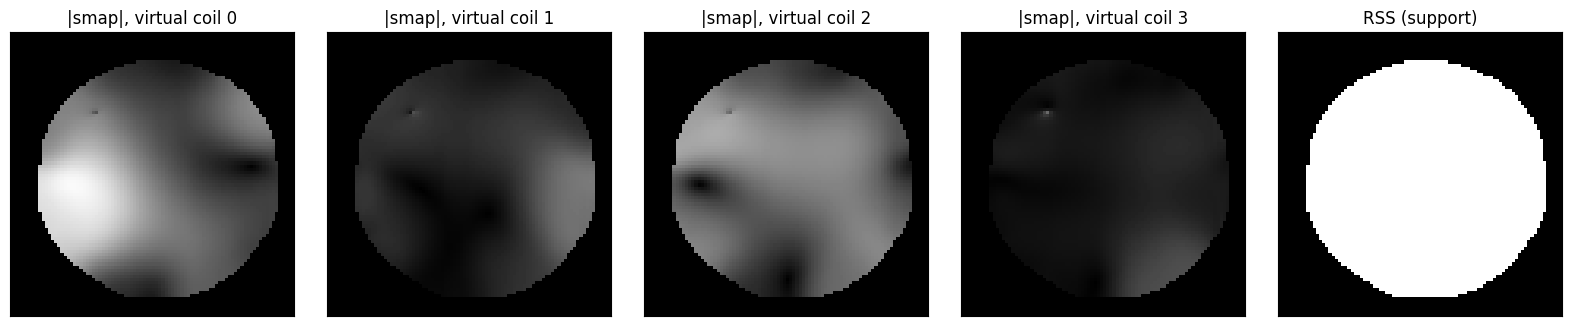

In [8]:
with h5py.File(out) as f:
    smaps = f["smaps"][()]
fig, ax = plt.subplots(1, 5, figsize=(16, 3.2))
for i, a_ in enumerate(ax[:4]):
    a_.imshow(np.abs(smaps[:, :, sp.Nz // 2, i]).T, origin="lower", cmap="gray", vmin=0, vmax=1)
    a_.set_title(f"|smap|, virtual coil {i}")
ax[4].imshow(np.sqrt((np.abs(smaps[:, :, sp.Nz // 2]) ** 2).sum(-1)).T, origin="lower", cmap="gray")
ax[4].set_title("RSS (support)")
for a_ in ax:
    a_.set_xticks([])
    a_.set_yticks([])
plt.tight_layout()
plt.show()

## 7. B0 field map

Fit on the deGRE grid by MRIFieldmaps.jl (`preprocess/julia/b0map.jl`) from the two echoes,
starting from a ROMEO-unwrapped phase difference and using the sensitivity maps for the
coil combine, then resized to the EPI grid. The QA figure shows the deGRE echoes, their
ratio, the starting point, the fit and the fit mask.

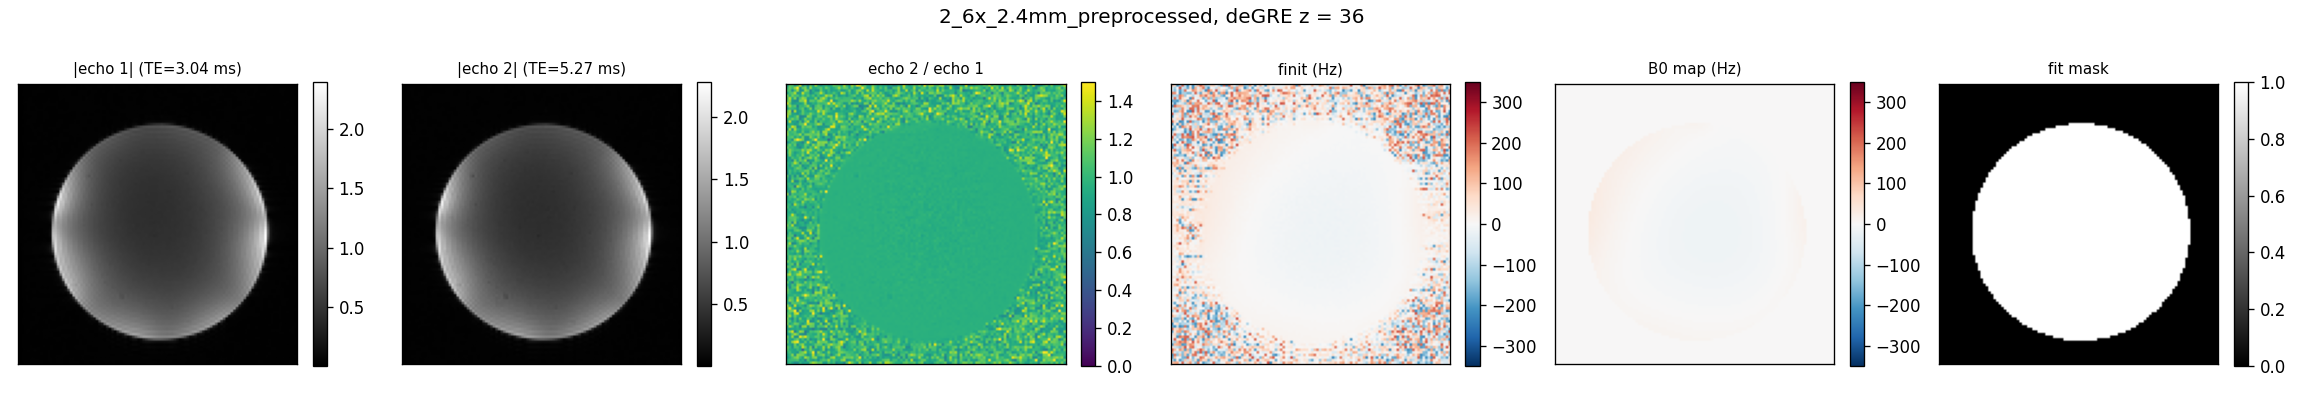

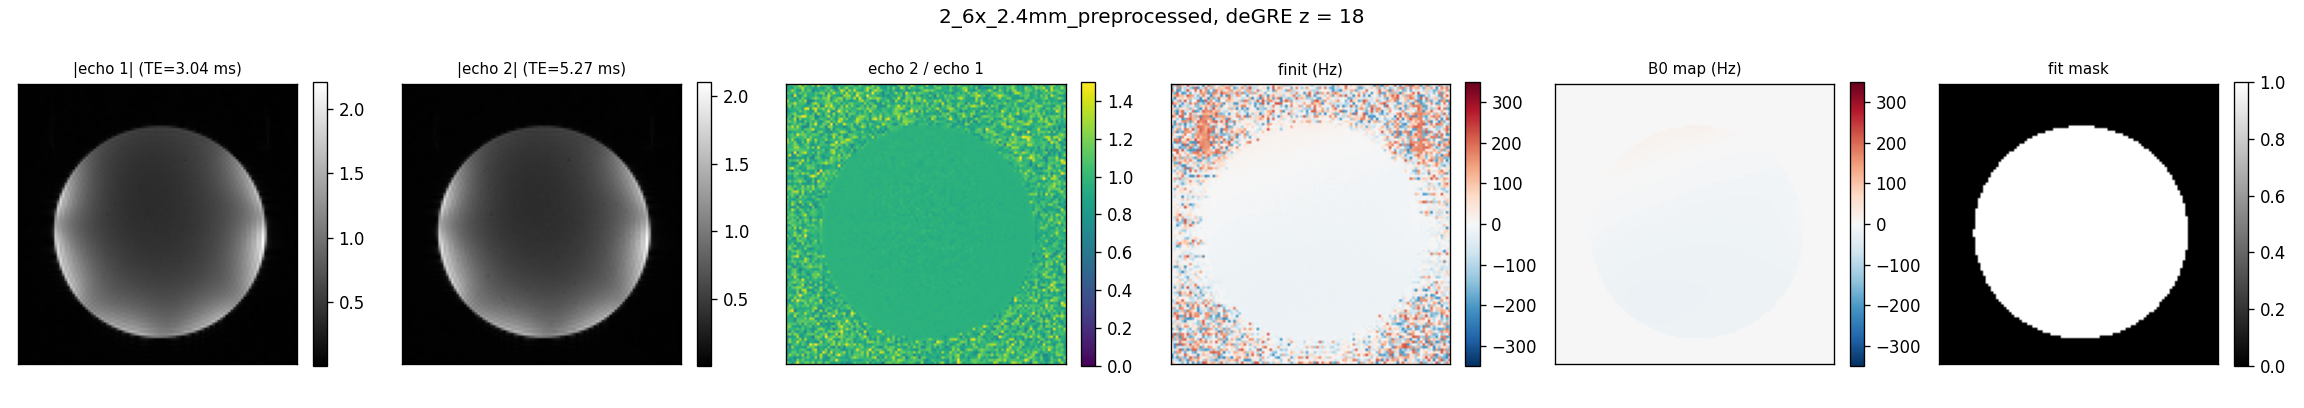

B0 on the EPI grid: (90, 90, 60), -189 to 42 Hz inside the mask


In [9]:
for png in utils.plot_gre_b0_diagnostics(out):
    display(Image(png, width=950))
with h5py.File(out) as f:
    b0, m = f["b0map_hz"][()], f["b0_mask"][()]
print(f"B0 on the EPI grid: {b0.shape}, {b0[m].min():.0f} to {b0[m].max():.0f} Hz inside the mask")

## 8. R2* map — a placeholder

Fit log-linearly over the deGRE echoes (`preprocess/r2star.py`). The two deGRE echoes are
only ~2.2 ms apart (their spacing is set for B0 mapping) while T2* here is ~47 ms, so the
signal changes by ~5% between them and the map is dominated by noise. A usable R2* map
needs a true multi-echo GRE; see the module docstring and `docs/TODO.md`.

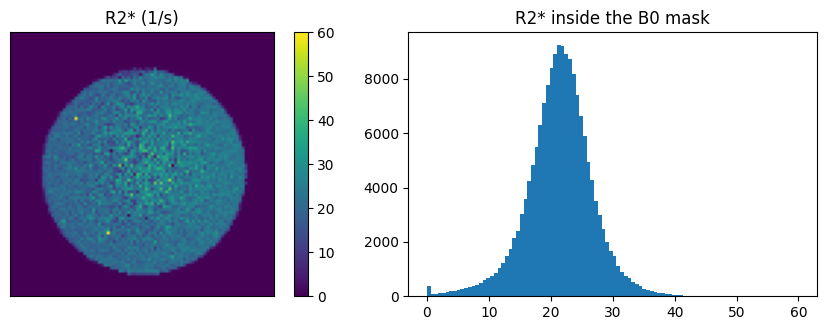

In [10]:
with h5py.File(out) as f:
    r2 = f["r2star"][()]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
im = ax[0].imshow(r2[:, :, sp.Nz // 2].T, origin="lower", vmin=0, vmax=60)
ax[0].set_title("R2* (1/s)")
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.colorbar(im, ax=ax[0])
ax[1].hist(r2[m], bins=100, range=(0, 60))
ax[1].set_title("R2* inside the B0 mask")
plt.tight_layout()
plt.show()

## 9. The output file

Everything `recon/` reads, plus provenance. `degre/` holds the deGRE-grid QA volumes.

In [11]:
with h5py.File(out) as f:
    f.visititems(lambda k, v: print(f"{k:22s} {v.shape} {v.dtype}")
                 if isinstance(v, h5py.Dataset) else None)
    for k, v in sorted(f.attrs.items()):
        print(f"  @{k} = {v}")

W                      (32, 32) complex64
b0_mask                (90, 90, 60) bool
b0map_hz               (90, 90, 60) float32
cc_evals               (90, 32) float32
cc_matrix              (90, 15, 32) complex64
degre/b0map_hz         (108, 108, 72) float32
degre/emap             (108, 108, 72) float32
degre/finit_hz         (108, 108, 72) float32
degre/img_echoes       (108, 108, 72, 2) float32
degre/mask             (108, 108, 72) bool
degre/r2star           (108, 108, 72) float32
degre/smaps            (108, 108, 72, 32) complex64
delay_sweep/a1         (241,) float64
delay_sweep/a2         (241,) float64
delay_sweep/delay      (241,) float64
delay_sweep/wrap_count (241,) int64
echo_times             (90, 60, 60) float64
ksp_calib              (90, 17, 11, 15, 60) complex64
ksp_epi_zf             (90, 90, 60, 15, 60) complex64
omegas                 (90, 60, 60) bool
r2star                 (90, 90, 60) float32
smaps                  (90, 90, 60, 15) complex64
  @Nc_out = 15
  @Ncoi

## Other settings, reusing the cache

With `keep_cache=True` the gridded k-space is kept, so rerunning with different
compression settings skips Stage A. Here: exactly 6 virtual coils and no maps.

In [12]:
t0 = time.time()
out6 = preprocess(replace(cfg, Nvcoils=6, estimate_smaps=False, estimate_b0=False,
                          estimate_r2star=False, keep_cache=False), SEQ)
with h5py.File(out6) as f:
    print(f["ksp_epi_zf"].shape, f.attrs["Nvcoils_source"], f"{time.time() - t0:.0f} s")

=== 2_6x_2.4mm ===
Stage A: using complete cache /home/rexfung/.claude/jobs/8dfd3ab3/tmp/val_demo2/2_6x_2.4mm_gridded.h5


  GCC: lowest per-x energy kept [0.628  0.6309 0.6439] at x = [88  2  3]
Coil compression (gcc): 32 -> 6 virtual coils (user; 94.72% of energy kept)


Calibration region: ky 37:54, kz 25:36
Stage B: writing /home/rexfung/.claude/jobs/8dfd3ab3/tmp/val_demo2/2_6x_2.4mm_preprocessed.h5


  thermal-noise variance of the output k-space: 0.9352


Done: /home/rexfung/.claude/jobs/8dfd3ab3/tmp/val_demo2/2_6x_2.4mm_preprocessed.h5
(90, 90, 60, 6, 60) user 82 s
